In [1]:
# Install required packages
!pip install -q xgboost shap imbalanced-learn plotly

In [2]:
# Core Libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# Visualisation
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Sklearn Preprocessing
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.pipeline import Pipeline

# Sklearn Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier

# Sklearn Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    ConfusionMatrixDisplay
)

# Imbalanced-learn
from imblearn.over_sampling import SMOTE

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    LSTM, Dense, Dropout, BatchNormalization, Bidirectional
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Explainability
import shap

# Misc
from google.colab import files

# Global style
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'font.family': 'DejaVu Sans'})
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(' All libraries imported successfully.')
print(f'   TensorFlow version : {tf.__version__}')
print(f'   GPU available      : {len(tf.config.list_physical_devices("GPU")) > 0}')

 All libraries imported successfully.
   TensorFlow version : 2.20.0
   GPU available      : False


In [3]:
# Upload Dataset
import zipfile
import io

print('Please upload dataset (ZIP or CSV)')
uploaded = files.upload()

file_name = list(uploaded.keys())[0]

# If ZIP file uploaded
if file_name.endswith('.zip'):
    with zipfile.ZipFile(io.BytesIO(uploaded[file_name])) as z:
        print(" Extracting ZIP...")
        z.extractall()

    # Find CSV inside extracted files
    for f in z.namelist():
        if f.endswith('.csv'):
            csv_file = f
            break

    df = pd.read_csv(csv_file)

# If CSV uploaded directly
else:
    df = pd.read_csv(file_name)

df_raw = df.copy()

print(f'\n Dataset loaded — shape: {df.shape}')
print(f'   Columns : {df.columns.tolist()}')
df.head()

Please upload dataset (ZIP or CSV)


Saving Predictive maintenance for manufacturing.zip to Predictive maintenance for manufacturing.zip
 Extracting ZIP...

 Dataset loaded — shape: (10000, 10)
   Columns : ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Target', 'Failure Type']


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Target,Failure Type
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,No Failure
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,No Failure
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,No Failure
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,No Failure
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,No Failure


Exploratory Data Analysis (EDA)

In [4]:
# Basic statistics
print('=' * 60)
print('DATASET OVERVIEW')
print('=' * 60)
print(f'Rows    : {df.shape[0]:,}')
print(f'Columns : {df.shape[1]}')
print(f'Memory  : {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
print()
print('Data Types:')
print(df.dtypes)
print()
print('Missing values per column:')
print(df.isnull().sum())
print()
print(f'Duplicate rows : {df.duplicated().sum()}')
print()
display(df.describe(include='all').T)

DATASET OVERVIEW
Rows    : 10,000
Columns : 10
Memory  : 2151.4 KB

Data Types:
UDI                          int64
Product ID                  object
Type                        object
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
Target                       int64
Failure Type                object
dtype: object

Missing values per column:
UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Target                     0
Failure Type               0
dtype: int64

Duplicate rows : 0



,count,unique,top,freq,mean,std,min,25%,50%,75%,max
UDI,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
Product ID,10000,10000,L57163,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,10000,3,L,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Air temperature [K],10000.0,NaN,NaN,NaN,300.00493,2.000259,295.3,298.3,300.1,301.5,304.5
Process temperature [K],10000.0,NaN,NaN,NaN,310.00556,1.483734,305.7,308.8,310.1,311.1,313.8
Rotational speed [rpm],10000.0,NaN,NaN,NaN,1538.7761,179.284096,1168.0,1423.0,1503.0,1612.0,2886.0
Torque [Nm],10000.0,NaN,NaN,NaN,39.98691,9.968934,3.8,33.2,40.1,46.8,76.6
Tool wear [min],10000.0,NaN,NaN,NaN,107.951,63.654147,0.0,53.0,108.0,162.0,253.0
Target,10000.0,NaN,NaN,NaN,0.0339,0.180981,0.0,0.0,0.0,0.0,1.0
Failure Type,10000,6,No Failure,9652,NaN,NaN,NaN,NaN,NaN,NaN,NaN


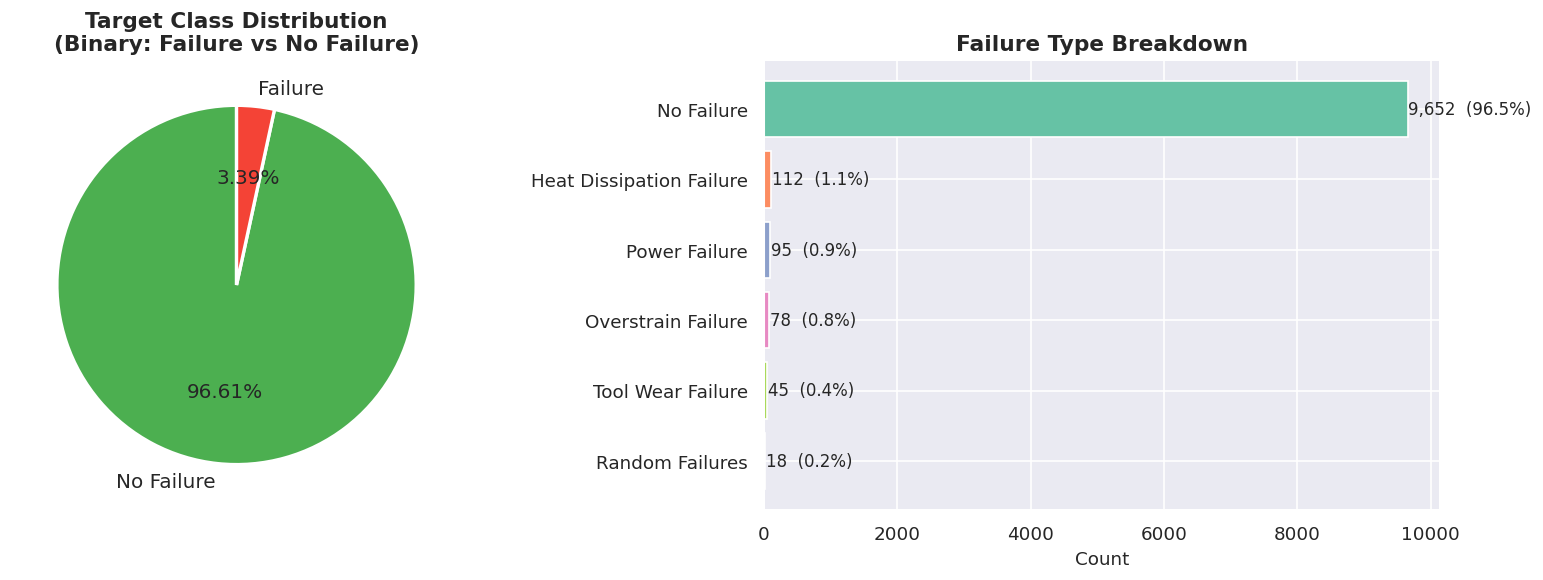


 Key Insight:
   The dataset is heavily imbalanced — only 3.4% of
   records represent machine failures. We will apply SMOTE to correct this.


In [5]:
# Target (failure) distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Binary target
counts = df['Target'].value_counts()
labels = ['No Failure', 'Failure']
colors = ['#4CAF50', '#F44336']
axes[0].pie(counts, labels=labels, autopct='%1.2f%%', colors=colors,
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2},
            textprops={'fontsize': 12})
axes[0].set_title('Target Class Distribution\n(Binary: Failure vs No Failure)', fontweight='bold')

# Multi-class failure types
failure_counts = df['Failure Type'].value_counts()
palette = sns.color_palette('Set2', len(failure_counts))
axes[1].barh(failure_counts.index, failure_counts.values, color=palette, edgecolor='white')
for i, v in enumerate(failure_counts.values):
    axes[1].text(v + 10, i, f'{v:,}  ({v/len(df)*100:.1f}%)', va='center', fontsize=10)
axes[1].set_title('Failure Type Breakdown', fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('eda_target_distribution.png', bbox_inches='tight')
plt.show()

print('\n Key Insight:')
print(f'   The dataset is heavily imbalanced — only {counts[1]/len(df)*100:.1f}% of')
print('   records represent machine failures. We will apply SMOTE to correct this.')

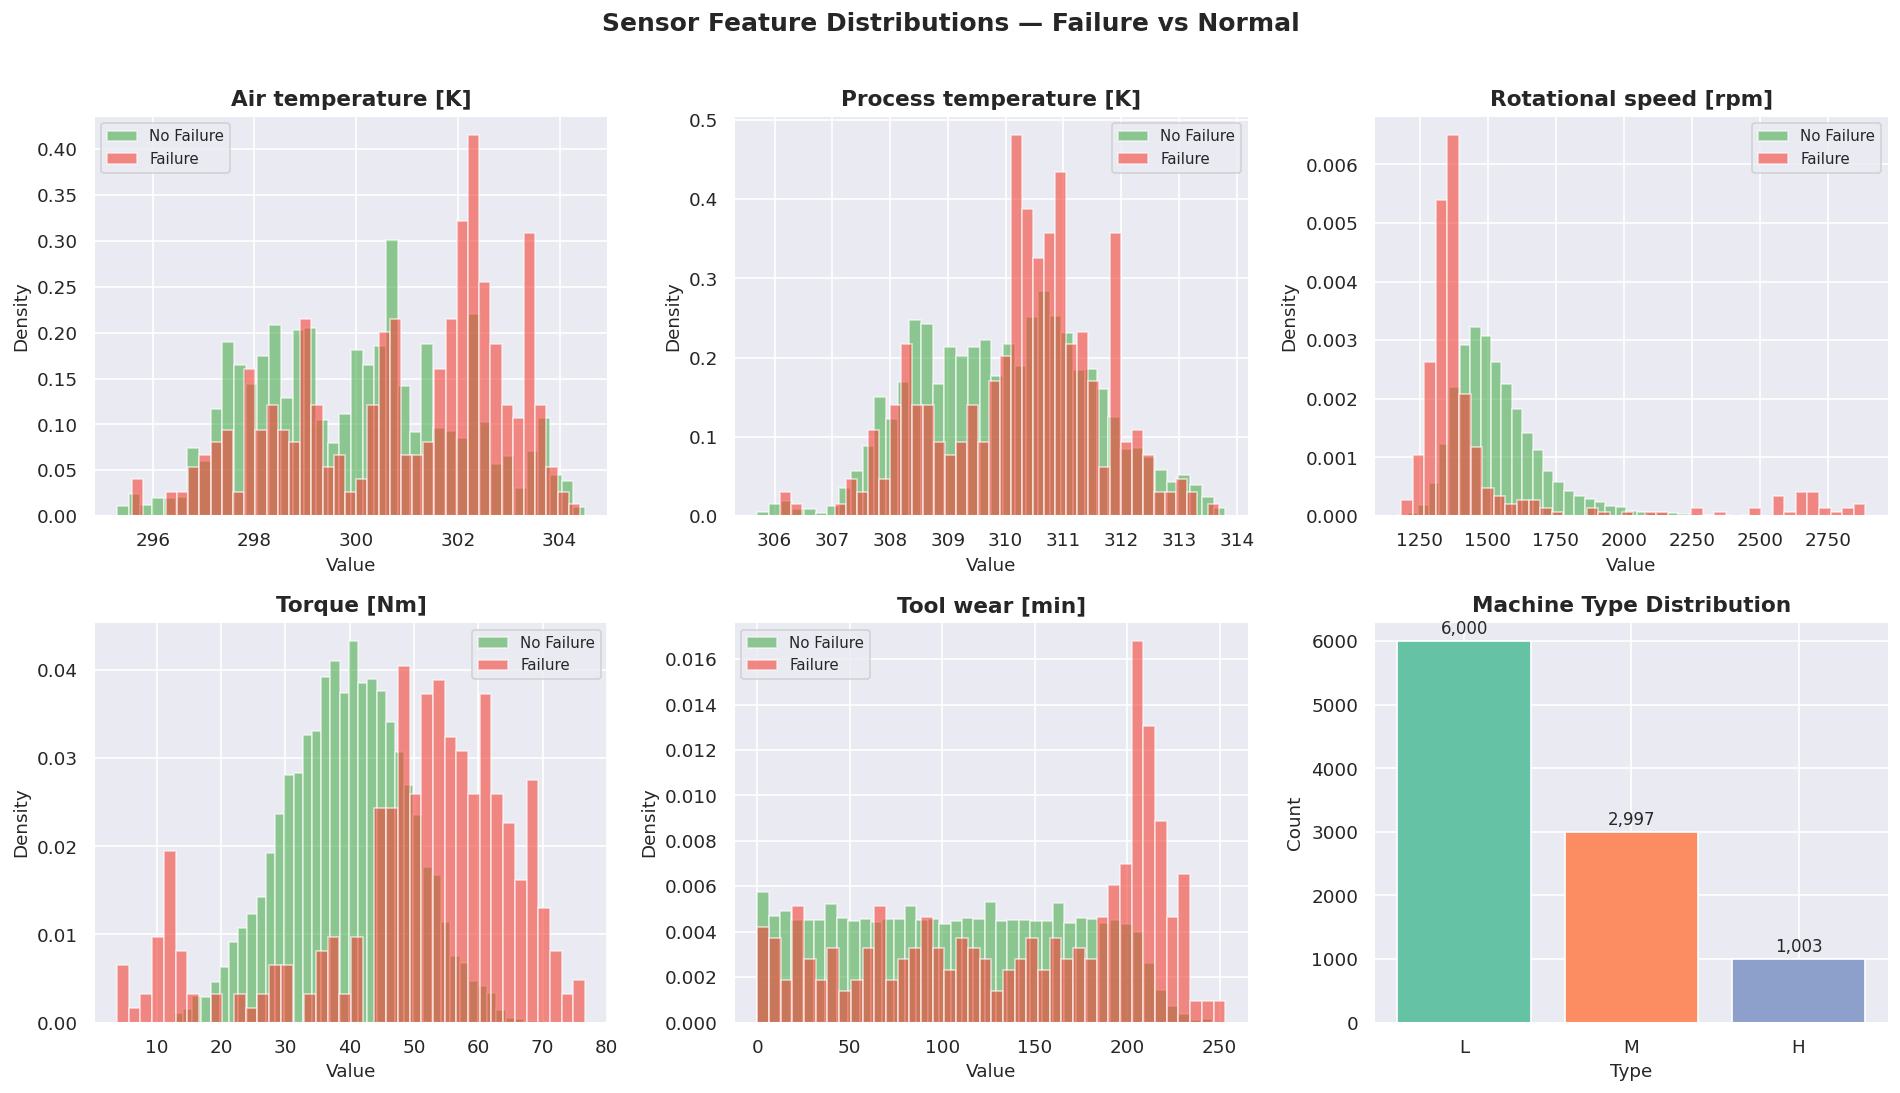


 Key Insights:
   • Tool wear and Torque show clear separation between failure / no-failure populations.
   • Rotational speed distribution is right-skewed for failing machines.


In [6]:
# Sensor feature distributions
sensor_cols = [
    'Air temperature [K]', 'Process temperature [K]',
    'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]'
]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for i, col in enumerate(sensor_cols):
    ax = axes[i]
    # Overlay distributions for failed vs normal
    for target, color, label in [(0, '#4CAF50', 'No Failure'), (1, '#F44336', 'Failure')]:
        subset = df[df['Target'] == target][col]
        ax.hist(subset, bins=40, alpha=0.6, color=color, label=label, density=True)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Value')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)

# Machine type distribution in last subplot
ax = axes[5]
type_counts = df['Type'].value_counts()
ax.bar(type_counts.index, type_counts.values,
       color=sns.color_palette('Set2', 3), edgecolor='white')
ax.set_title('Machine Type Distribution', fontweight='bold')
ax.set_xlabel('Type')
ax.set_ylabel('Count')
for xi, yi in zip(type_counts.index, type_counts.values):
    ax.text(xi, yi + 50, f'{yi:,}', ha='center', va='bottom', fontsize=10)

plt.suptitle('Sensor Feature Distributions — Failure vs Normal', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_sensor_distributions.png', bbox_inches='tight')
plt.show()

print('\n Key Insights:')
print('   • Tool wear and Torque show clear separation between failure / no-failure populations.')
print('   • Rotational speed distribution is right-skewed for failing machines.')

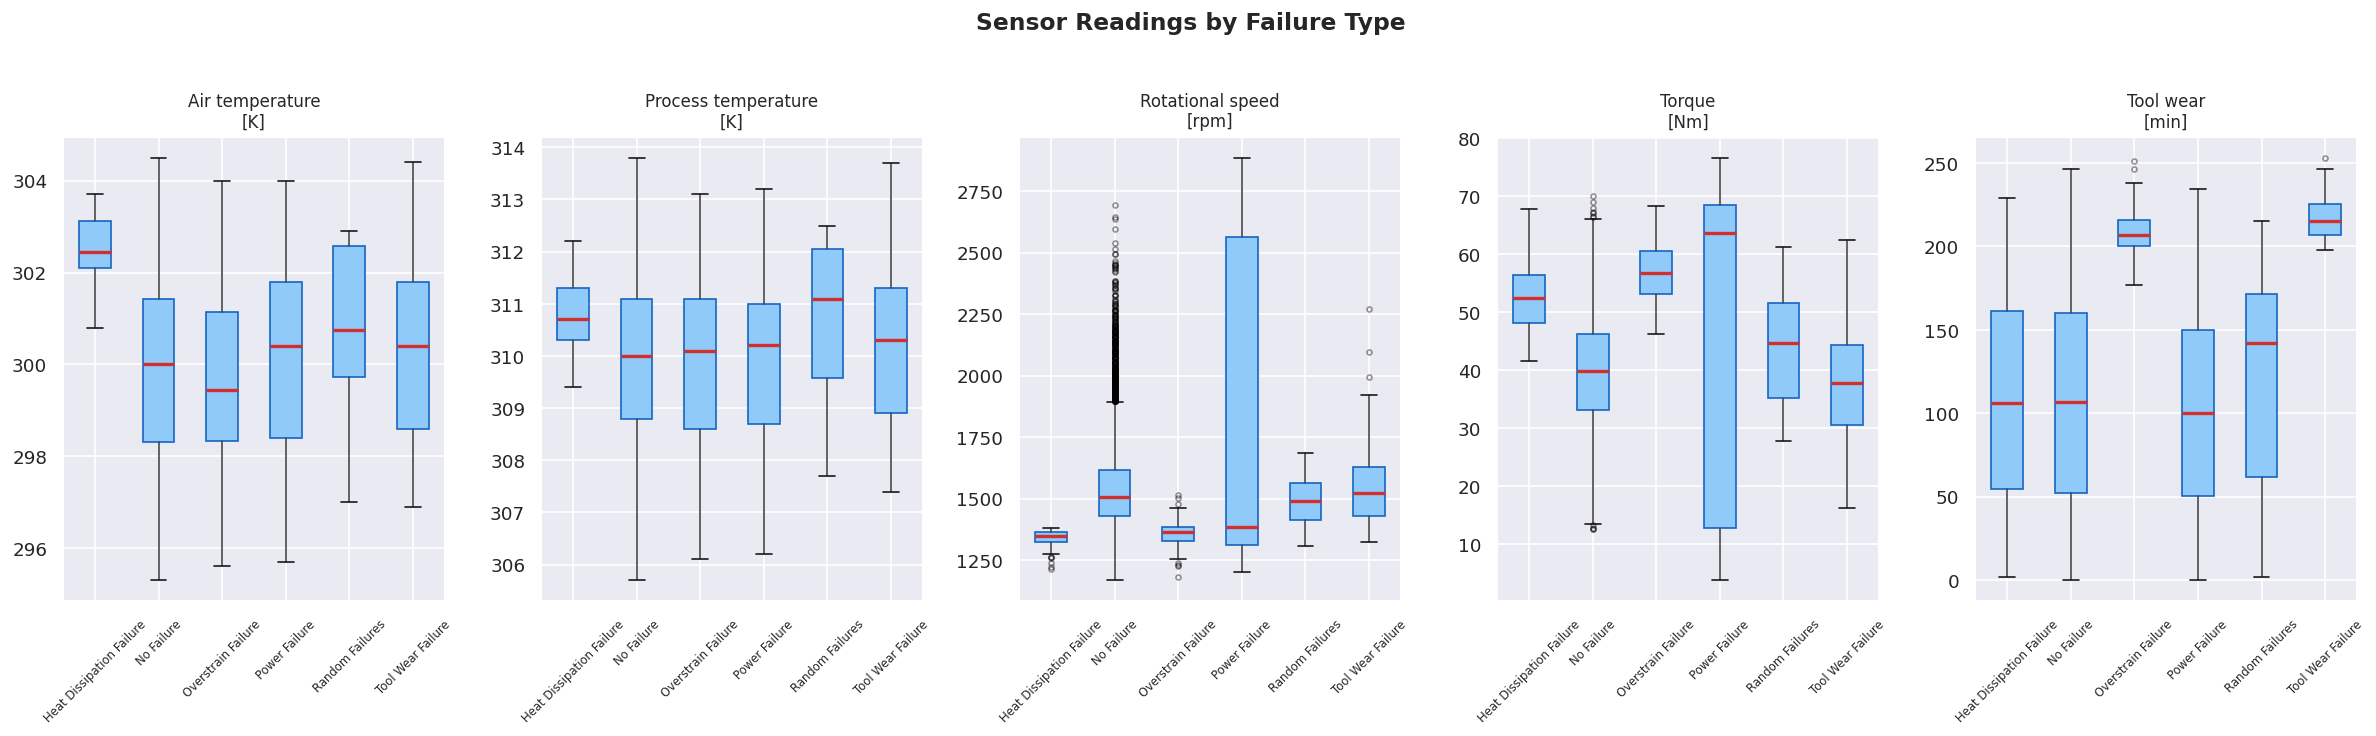

In [7]:
# Box-plots of sensor readings by failure type
fig, axes = plt.subplots(1, len(sensor_cols), figsize=(20, 6))

for i, col in enumerate(sensor_cols):
    df.boxplot(
        column=col, by='Failure Type', ax=axes[i],
        notch=False, vert=True, patch_artist=True,
        boxprops=dict(facecolor='#90CAF9', color='#1565C0'),
        medianprops=dict(color='#D32F2F', linewidth=2),
        flierprops=dict(marker='o', markersize=3, alpha=0.4)
    )
    axes[i].set_title(col.replace(' [', '\n['), fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=45, labelsize=7)
    plt.sca(axes[i])
    plt.title(col.replace(' [', '\n['), fontsize=10)

plt.suptitle('Sensor Readings by Failure Type', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('eda_boxplots_by_failure.png', bbox_inches='tight')
plt.show()

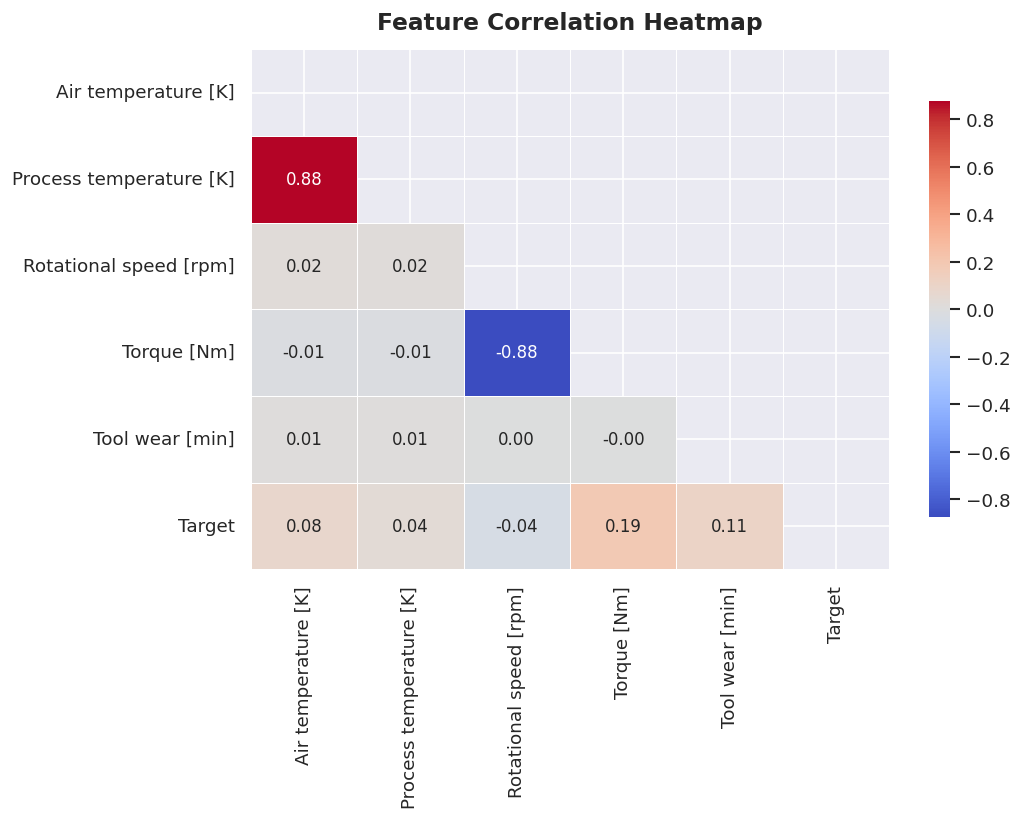


 Key Insights:
   • Air temp and Process temp are highly correlated (expected — thermally linked).
   • Torque and Rotational speed show a strong negative correlation.
   • Tool wear has a moderate positive correlation with failure.


In [8]:
# Correlation heatmap
numeric_df = df.select_dtypes(include=np.number).drop(columns=['UDI'])
corr = numeric_df.corr()

mask = np.triu(np.ones_like(corr, dtype=bool))
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr, mask=mask, annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5,
    annot_kws={'size': 10}, ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Heatmap', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('eda_correlation_heatmap.png', bbox_inches='tight')
plt.show()

print('\n Key Insights:')
print('   • Air temp and Process temp are highly correlated (expected — thermally linked).')
print('   • Torque and Rotational speed show a strong negative correlation.')
print('   • Tool wear has a moderate positive correlation with failure.')

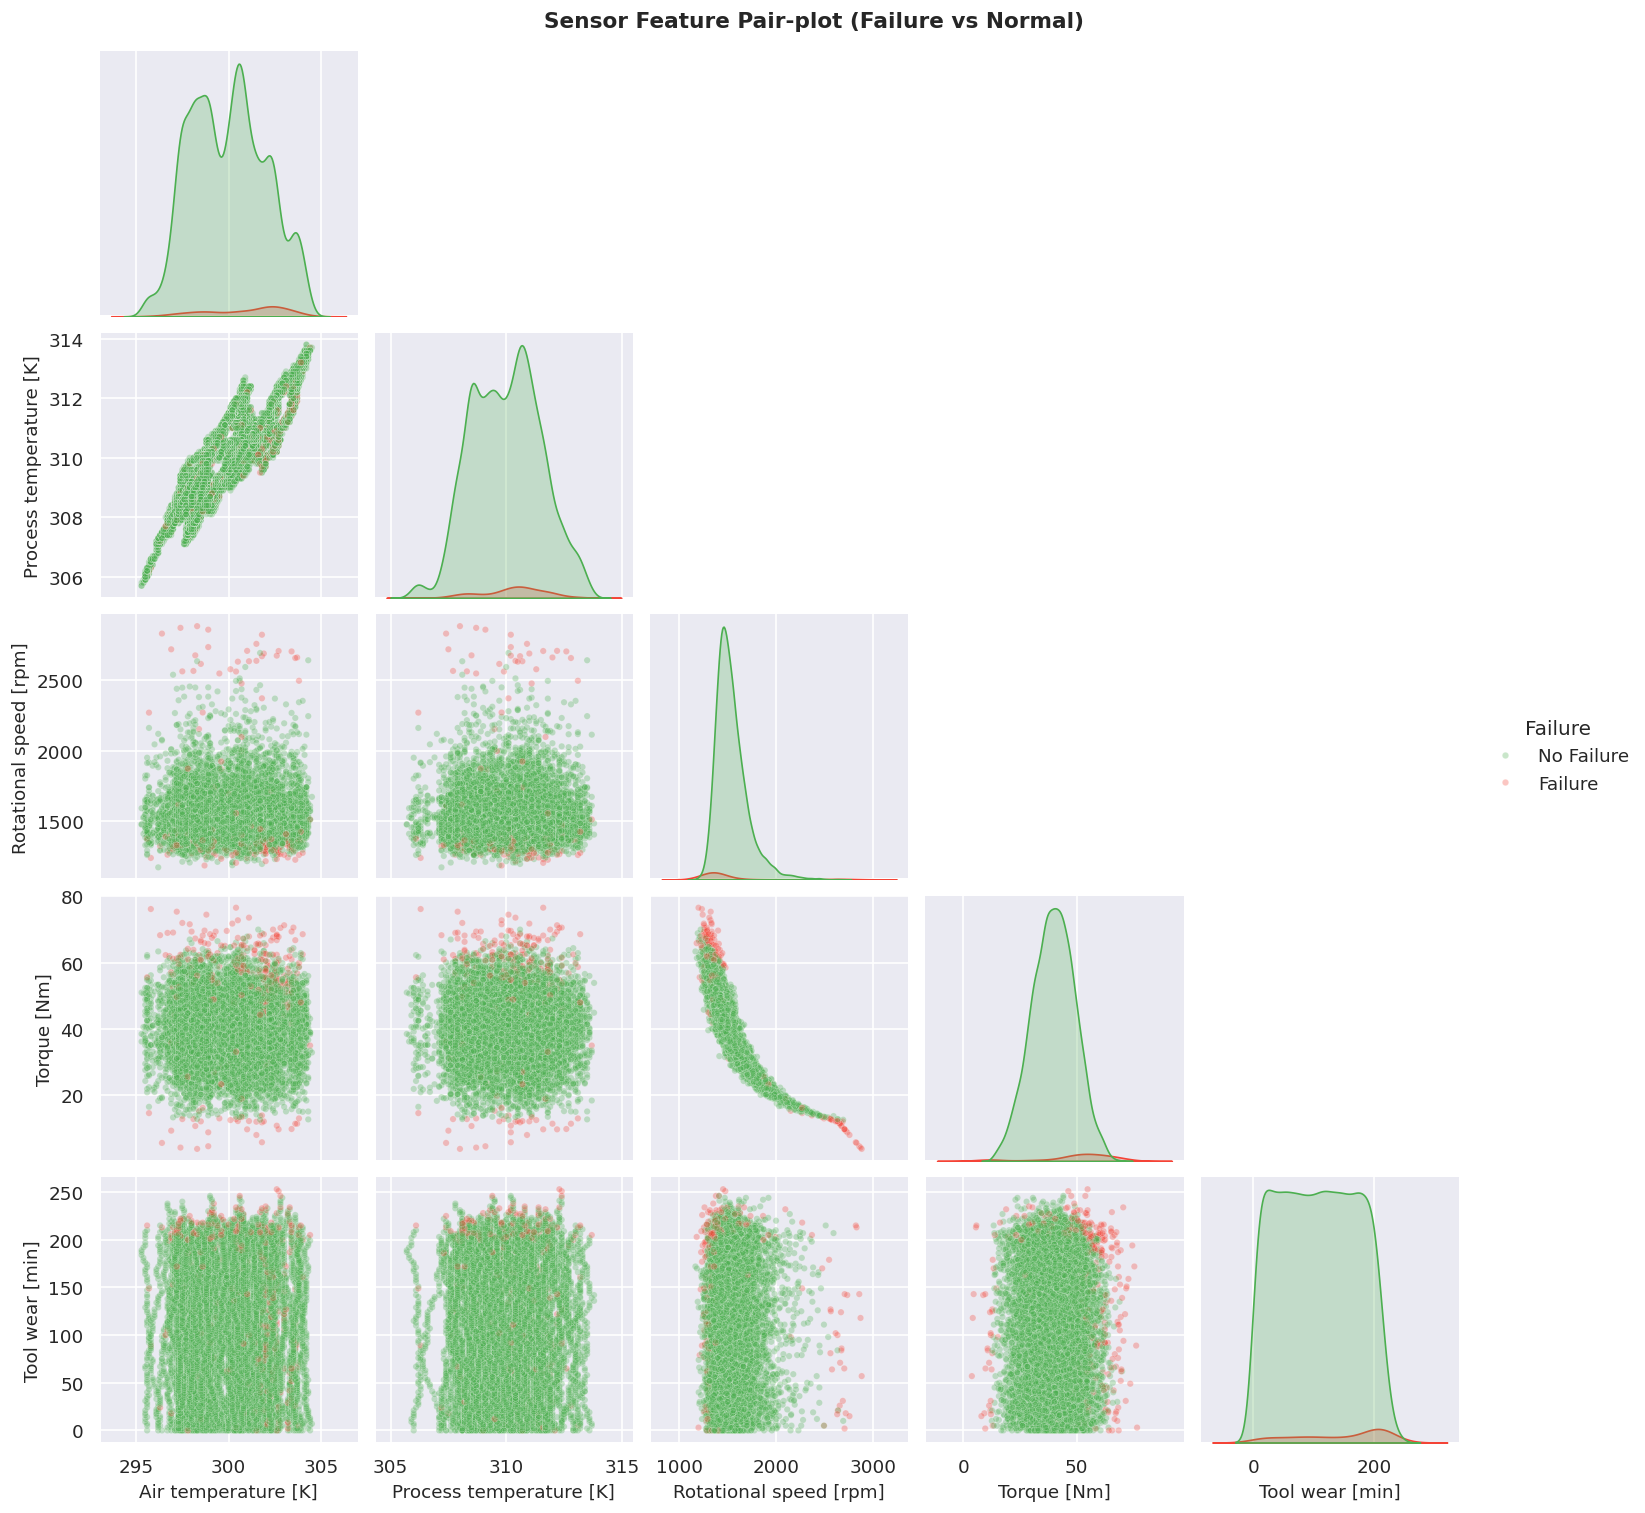


 Torque × Tool wear interaction appears most predictive of failure.


In [9]:
# Pairplot for sensor features
pair_df = df[sensor_cols + ['Target']].copy()
pair_df['Failure'] = pair_df['Target'].map({0: 'No Failure', 1: 'Failure'})

g = sns.pairplot(
    pair_df.drop(columns='Target'),
    hue='Failure', diag_kind='kde',
    plot_kws={'alpha': 0.3, 's': 15},
    palette={'No Failure': '#4CAF50', 'Failure': '#F44336'},
    corner=True
)
g.figure.suptitle('Sensor Feature Pair-plot (Failure vs Normal)', y=1.01,
                  fontsize=13, fontweight='bold')
plt.savefig('eda_pairplot.png', bbox_inches='tight')
plt.show()
print('\n Torque × Tool wear interaction appears most predictive of failure.')

In [10]:
# Outlier detection via IQR
print('Outlier summary (IQR method):')
print('-' * 50)
for col in sensor_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()
    print(f'  {col:<35} : {n_out:>4} outliers  ({n_out/len(df)*100:.2f}%)')

print()
print(' Note: Outliers in sensor data often correspond to actual fault events.')
print('   We will retain them as they carry strong predictive signal.')

Outlier summary (IQR method):
--------------------------------------------------
  Air temperature [K]                 :    0 outliers  (0.00%)
  Process temperature [K]             :    0 outliers  (0.00%)
  Rotational speed [rpm]              :  418 outliers  (4.18%)
  Torque [Nm]                         :   69 outliers  (0.69%)
  Tool wear [min]                     :    0 outliers  (0.00%)

 Note: Outliers in sensor data often correspond to actual fault events.
   We will retain them as they carry strong predictive signal.


Data Processing

In [11]:
# Drop non-predictive columns
df_proc = df.drop(columns=['UDI', 'Product ID', 'Failure Type'])

# Encode machine type (L=0, M=1, H=2 — ordinal; represents quality tier)
type_map = {'L': 0, 'M': 1, 'H': 2}
df_proc['Type'] = df_proc['Type'].map(type_map)

# Split features and target
X = df_proc.drop(columns=['Target'])
y = df_proc['Target']

print(f'Feature matrix shape : {X.shape}')
print(f'Target vector shape  : {y.shape}')
print(f'\nFeatures used:\n{X.columns.tolist()}')
print(f'\nClass balance before SMOTE: {y.value_counts().to_dict()}')

# Train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

# SMOTE on training set
smote = SMOTE(random_state=SEED)
X_train_sm, y_train_sm = smote.fit_resample(X_train_sc, y_train)

print(f'\n Class balance after SMOTE  : {pd.Series(y_train_sm).value_counts().to_dict()}')
print(' Preprocessing complete.')

Feature matrix shape : (10000, 6)
Target vector shape  : (10000,)

Features used:
['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

Class balance before SMOTE: {0: 9661, 1: 339}

 Class balance after SMOTE  : {0: 7729, 1: 7729}
 Preprocessing complete.


Feature Engineering

New features added: ['temp_diff', 'power', 'wear_rate', 'torque_per_rpm', 'heat_index', 'tool_wear_sq']
Engineered feature matrix shape: (10000, 12)


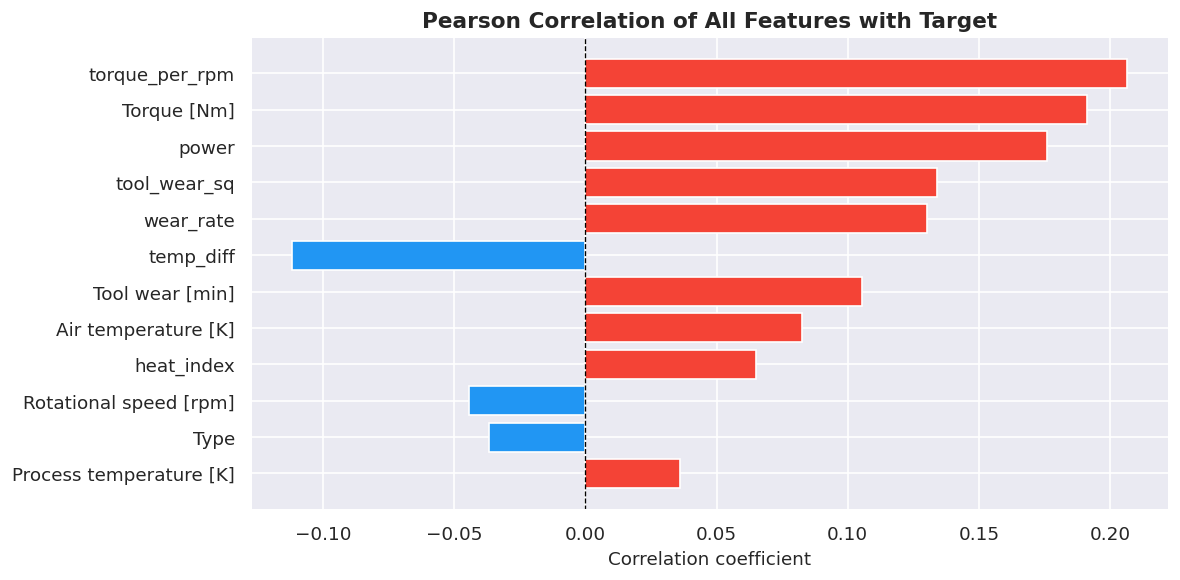

In [12]:
def engineer_features(df_in: pd.DataFrame) -> pd.DataFrame:
    df_fe = df_in.copy()

    df_fe['temp_diff']       = df_fe['Process temperature [K]'] - df_fe['Air temperature [K]']
    df_fe['power']           = df_fe['Torque [Nm]'] * df_fe['Rotational speed [rpm]'] * (2 * np.pi / 60)
    df_fe['wear_rate']       = df_fe['Tool wear [min]'] / (df_fe['Rotational speed [rpm]'] + 1e-6)
    df_fe['torque_per_rpm']  = df_fe['Torque [Nm]'] / (df_fe['Rotational speed [rpm]'] + 1e-6)
    df_fe['heat_index']      = df_fe['Air temperature [K]'] * df_fe['Process temperature [K]'] / 1e5
    df_fe['tool_wear_sq']    = df_fe['Tool wear [min]'] ** 2

    return df_fe

# Applied to the original (pre-split) processed frame
df_fe = engineer_features(df_proc)
X_fe  = df_fe.drop(columns=['Target'])
y_fe  = df_fe['Target']

X_train_fe, X_test_fe, y_train_fe, y_test_fe = train_test_split(
    X_fe, y_fe, test_size=0.20, random_state=SEED, stratify=y_fe
)

scaler_fe = StandardScaler()
X_train_fe_sc = scaler_fe.fit_transform(X_train_fe)
X_test_fe_sc  = scaler_fe.transform(X_test_fe)

X_train_fe_sm, y_train_fe_sm = smote.fit_resample(X_train_fe_sc, y_train_fe)

print('New features added:', [c for c in X_fe.columns if c not in X.columns])
print(f'Engineered feature matrix shape: {X_fe.shape}')

# Visualise feature importance preview via simple correlation
corr_with_target = df_fe.corr()['Target'].drop('Target').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#F44336' if v > 0 else '#2196F3' for v in corr_with_target]
ax.barh(corr_with_target.index[::-1], corr_with_target.values[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Pearson Correlation of All Features with Target', fontweight='bold')
ax.set_xlabel('Correlation coefficient')
plt.tight_layout()
plt.savefig('fe_correlation_with_target.png', bbox_inches='tight')
plt.show()

Machine Learning Models

- **Logistic Regression** — linear baseline
- **Random Forest** — ensemble of decision trees
- **XGBoost** — gradient-boosted trees
- **Gradient Boosting** — sklearn GBM for comparison

In [13]:
# Define models
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, C=1.0, solver='lbfgs', random_state=SEED
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=12, min_samples_leaf=2,
        class_weight='balanced', random_state=SEED, n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        scale_pos_weight=len(y_train_fe[y_train_fe==0]) / len(y_train_fe[y_train_fe==1]),
        use_label_encoder=False, eval_metric='logloss',
        random_state=SEED, n_jobs=-1
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=5,
        random_state=SEED
    )
}

# Train and evaluate
results = {}

for name, model in models.items():
    print(f' Training {name}…', end=' ')
    model.fit(X_train_fe_sm, y_train_fe_sm)
    y_pred  = model.predict(X_test_fe_sc)
    y_proba = model.predict_proba(X_test_fe_sc)[:, 1]

    results[name] = {
        'Accuracy' : accuracy_score(y_test_fe, y_pred),
        'Precision': precision_score(y_test_fe, y_pred),
        'Recall'   : recall_score(y_test_fe, y_pred),
        'F1 Score' : f1_score(y_test_fe, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test_fe, y_proba),
        'y_pred'   : y_pred,
        'y_proba'  : y_proba,
    }
    print(f'done  ✓  ROC-AUC = {results[name]["ROC-AUC"]:.4f}')

print('\n All ML models trained.')

 Training Logistic Regression… done  ✓  ROC-AUC = 0.9375
 Training Random Forest… done  ✓  ROC-AUC = 0.9829
 Training XGBoost… done  ✓  ROC-AUC = 0.9772
 Training Gradient Boosting… done  ✓  ROC-AUC = 0.9819

 All ML models trained.


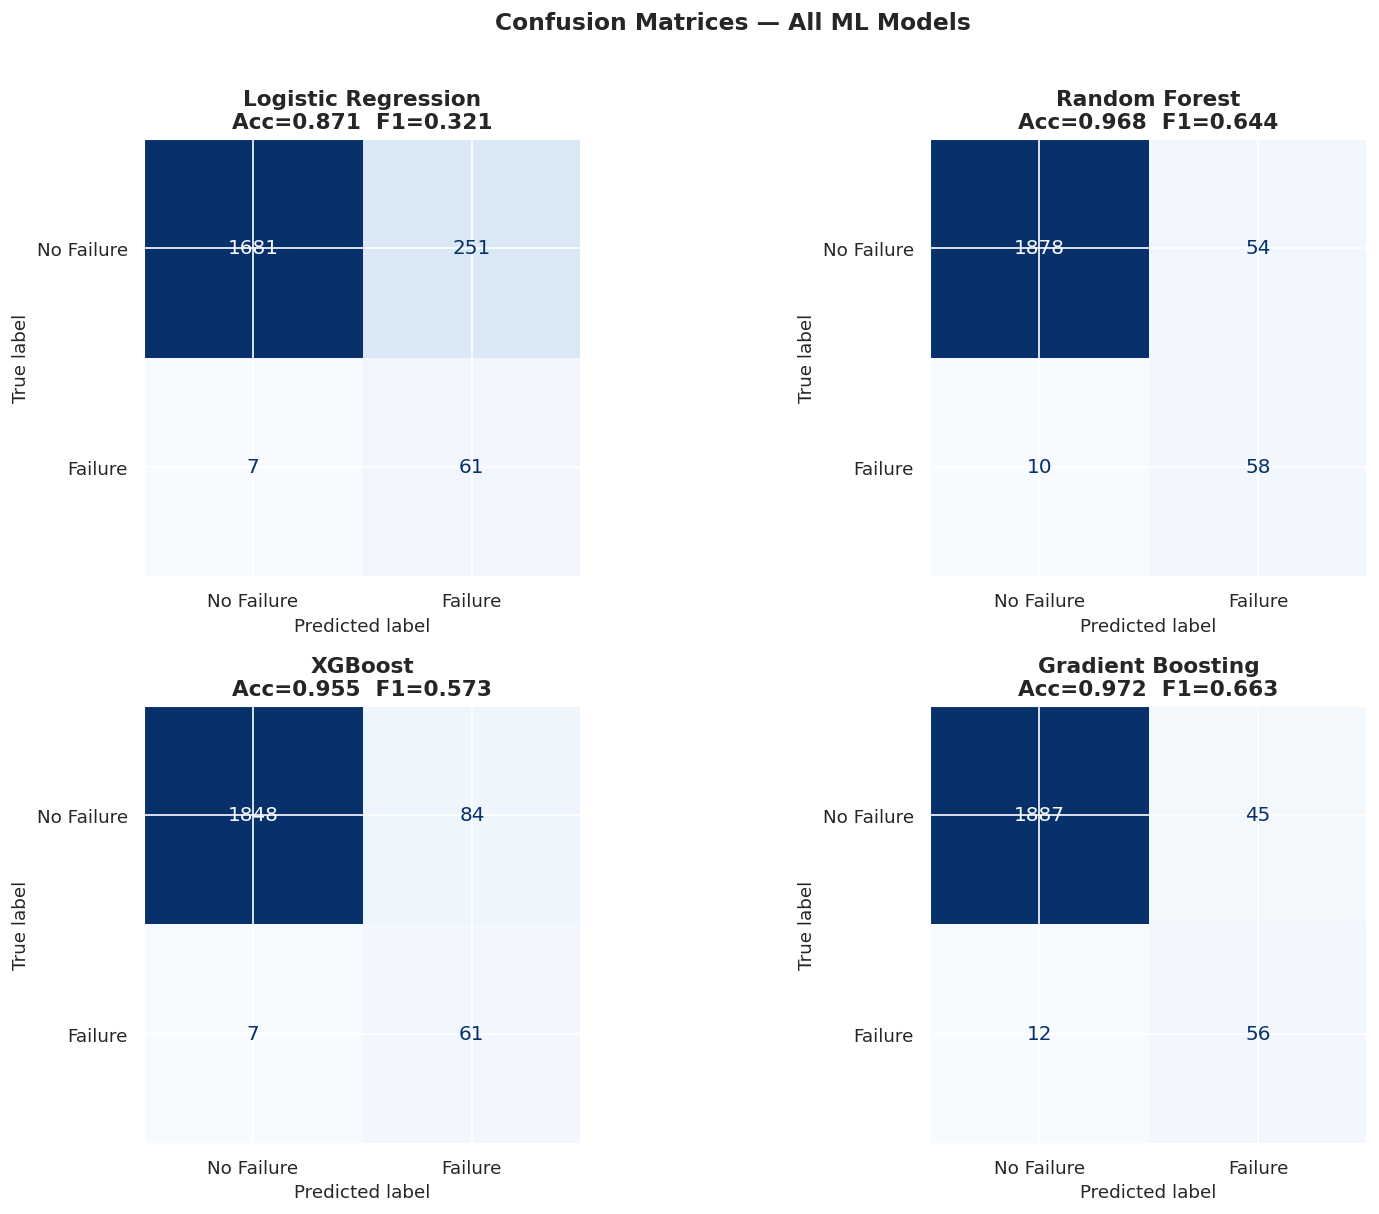

In [14]:
# Confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, (name, res) in enumerate(results.items()):
    cm = confusion_matrix(y_test_fe, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Failure', 'Failure'])
    disp.plot(ax=axes[i], colorbar=False, cmap='Blues')
    axes[i].set_title(f'{name}\nAcc={res["Accuracy"]:.3f}  F1={res["F1 Score"]:.3f}',
                      fontweight='bold')

plt.suptitle('Confusion Matrices — All ML Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('ml_confusion_matrices.png', bbox_inches='tight')
plt.show()

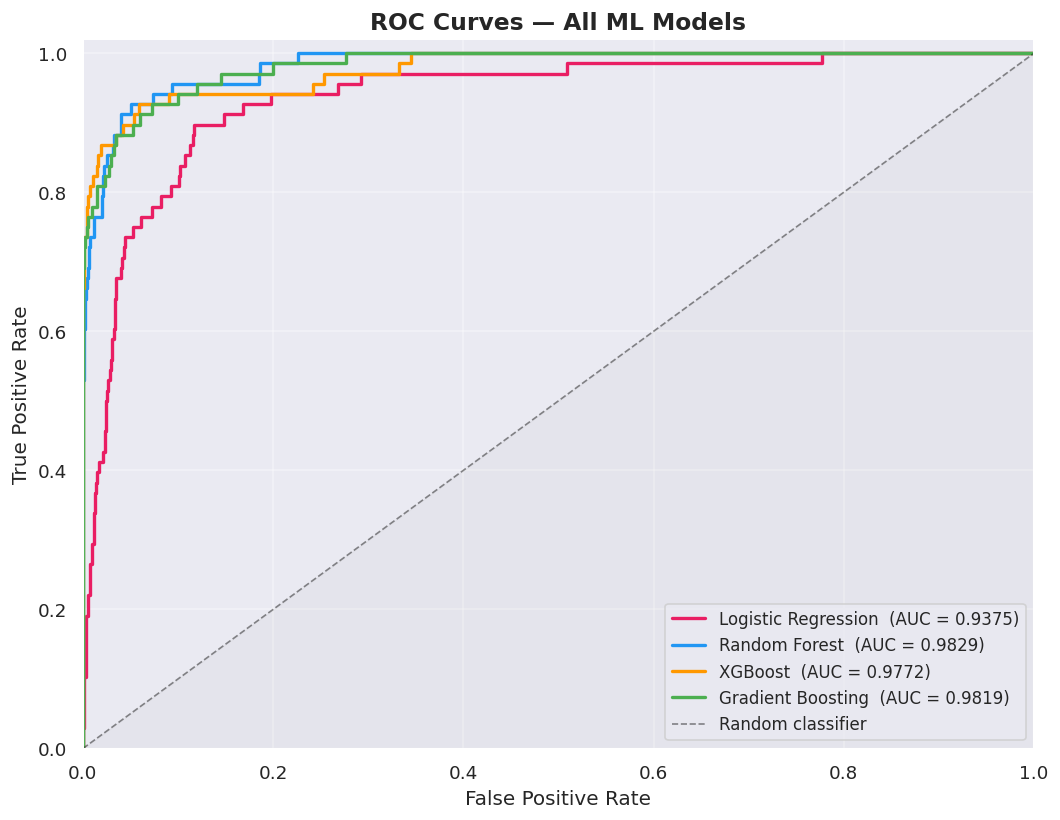

In [15]:
# ROC curves
fig, ax = plt.subplots(figsize=(9, 7))

palette_roc = ['#E91E63', '#2196F3', '#FF9800', '#4CAF50']

for (name, res), color in zip(results.items(), palette_roc):
    fpr, tpr, _ = roc_curve(y_test_fe, res['y_proba'])
    ax.plot(fpr, tpr, color=color, linewidth=2,
            label=f"{name}  (AUC = {res['ROC-AUC']:.4f})")

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random classifier')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='grey')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All ML Models', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('ml_roc_curves.png', bbox_inches='tight')
plt.show()

In [16]:
# Full classification reports
for name, res in results.items():
    print(f'\n{"-"*50}')
    print(f'  {name}')
    print(f'{"-"*50}')
    print(classification_report(y_test_fe, res['y_pred'],
                                target_names=['No Failure', 'Failure']))


--------------------------------------------------
  Logistic Regression
--------------------------------------------------
              precision    recall  f1-score   support

  No Failure       1.00      0.87      0.93      1932
     Failure       0.20      0.90      0.32        68

    accuracy                           0.87      2000
   macro avg       0.60      0.88      0.62      2000
weighted avg       0.97      0.87      0.91      2000


--------------------------------------------------
  Random Forest
--------------------------------------------------
              precision    recall  f1-score   support

  No Failure       0.99      0.97      0.98      1932
     Failure       0.52      0.85      0.64        68

    accuracy                           0.97      2000
   macro avg       0.76      0.91      0.81      2000
weighted avg       0.98      0.97      0.97      2000


--------------------------------------------------
  XGBoost
----------------------------------------

Deep Learning — Bidirectional LSTM


In [17]:
# Build sliding-window sequences
WINDOW = 10   # look-back window size

def create_sequences(X_arr, y_arr, window=10):
    """Create overlapping windows of shape (n_samples, window, n_features)."""
    Xs, ys = [], []
    for i in range(len(X_arr) - window):
        Xs.append(X_arr[i : i + window])
        ys.append(y_arr[i + window])
    return np.array(Xs), np.array(ys)


# Use the original (non-SMOTE) scaled sets to preserve temporal order
X_train_seq, y_train_seq = create_sequences(
    X_train_fe_sc, y_train_fe.values, window=WINDOW
)
X_test_seq, y_test_seq = create_sequences(
    X_test_fe_sc, y_test_fe.values, window=WINDOW
)

print(f'LSTM training sequences  : {X_train_seq.shape}')
print(f'LSTM test sequences      : {X_test_seq.shape}')

# Compute class weight to handle imbalance
n_pos = y_train_seq.sum()
n_neg = len(y_train_seq) - n_pos
class_weight_lstm = {0: 1.0, 1: n_neg / max(n_pos, 1)}
print(f'Class weight applied     : {class_weight_lstm}')

LSTM training sequences  : (7990, 10, 12)
LSTM test sequences      : (1990, 10, 12)
Class weight applied     : {0: 1.0, 1: np.float64(28.48339483394834)}


In [18]:
# Build Bidirectional LSTM
n_features = X_train_seq.shape[2]

def build_lstm(n_features, window):
    model = Sequential([
        Bidirectional(LSTM(128, return_sequences=True), input_shape=(window, n_features)),
        BatchNormalization(),
        Dropout(0.30),

        LSTM(64, return_sequences=False),
        BatchNormalization(),
        Dropout(0.20),

        Dense(32, activation='relu'),
        Dropout(0.10),
        Dense(1,  activation='sigmoid')
    ])
    model.compile(
        optimizer=Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc'),
                 tf.keras.metrics.Precision(name='precision'),
                 tf.keras.metrics.Recall(name='recall')]
    )
    return model


lstm_model = build_lstm(n_features, WINDOW)
lstm_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 10, 256)        │       144,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 10, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        82,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 229,953 (898.25 KB)

 Trainable params: 229,313 (895.75 KB)

 Non-trainable params: 640 (2.50 KB)

In [19]:
# Train LSTM
callbacks = [
    EarlyStopping(monitor='val_auc', patience=8, mode='max',
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, verbose=1)
]

history = lstm_model.fit(
    X_train_seq, y_train_seq,
    epochs=60,
    batch_size=64,
    validation_split=0.15,
    class_weight=class_weight_lstm,
    callbacks=callbacks,
    verbose=1
)

print('\n LSTM training complete.')

Epoch 1/60
107/107 ━━━━━━━━━━━━━━━━━━━━ 9s 44ms/step - accuracy: 0.4677 - auc: 0.5031 - loss: 1.5577 - precision: 0.0318 - recall: 0.5134 - val_accuracy: 0.7415 - val_auc: 0.5211 - val_loss: 0.6633 - val_precision: 0.0287 - val_recall: 0.1702 - learning_rate: 0.0010
Epoch 2/60
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 34ms/step - accuracy: 0.5544 - auc: 0.5732 - loss: 1.3740 - precision: 0.0413 - recall: 0.5625 - val_accuracy: 0.8115 - val_auc: 0.5023 - val_loss: 0.6017 - val_precision: 0.0214 - val_recall: 0.0851 - learning_rate: 0.0010
Epoch 3/60
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - accuracy: 0.5830 - auc: 0.6281 - loss: 1.2920 - precision: 0.0450 - recall: 0.5759 - val_accuracy: 0.7164 - val_auc: 0.4659 - val_loss: 0.5952 - val_precision: 0.0289 - val_recall: 0.1915 - learning_rate: 0.0010
Epoch 4/60
107/107 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - accuracy: 0.5948 - auc: 0.6576 - loss: 1.2599 - precision: 0.0495 - recall: 0.6205 - val_accuracy: 0.7039 - val_auc: 0.4833 - val_loss: 0.5920 -

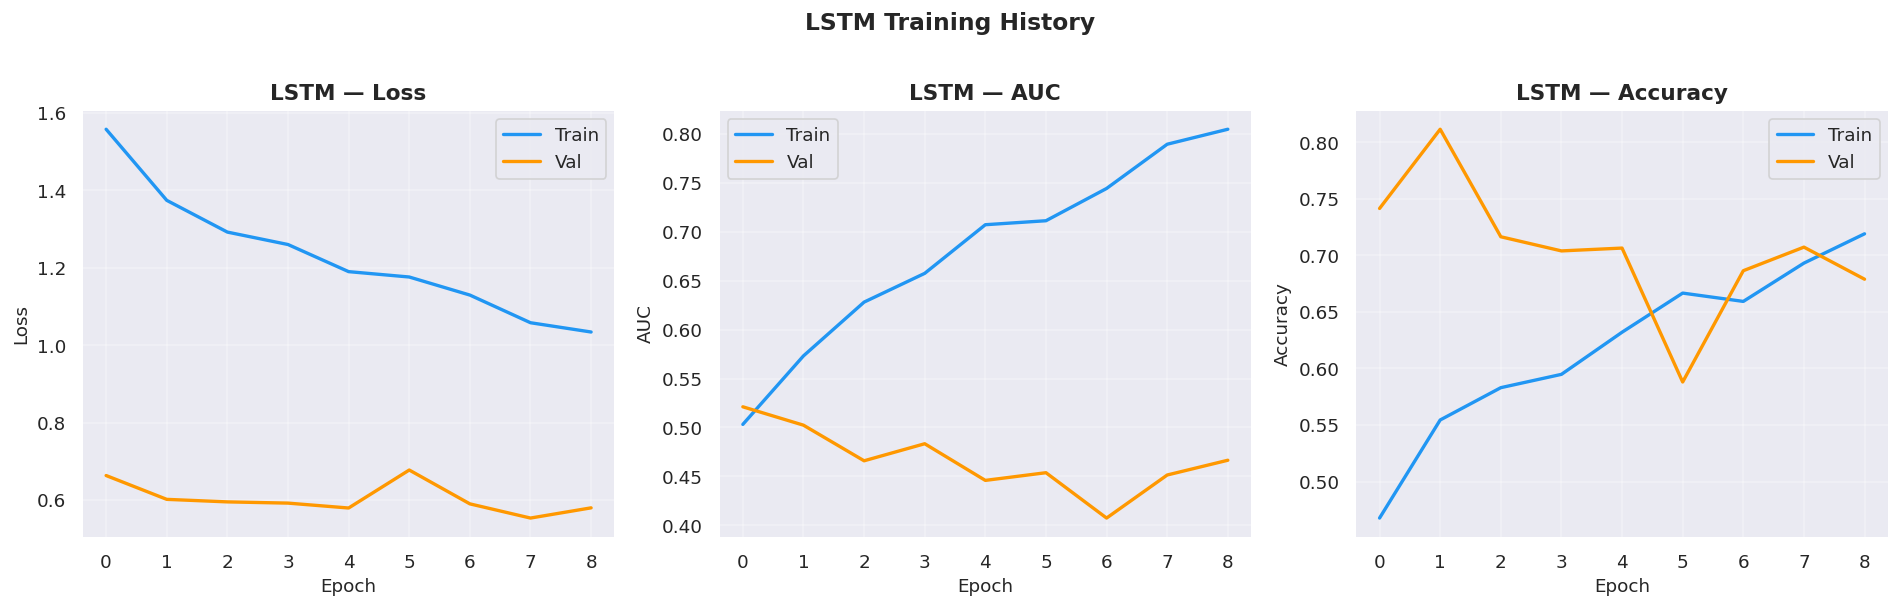

In [20]:
# Training history
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metrics = [('loss', 'Loss'), ('auc', 'AUC'), ('accuracy', 'Accuracy')]
for ax, (metric, label) in zip(axes, metrics):
    ax.plot(history.history[metric],           label='Train', color='#2196F3', linewidth=2)
    ax.plot(history.history[f'val_{metric}'],  label='Val',   color='#FF9800', linewidth=2)
    ax.set_title(f'LSTM — {label}', fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.set_ylabel(label)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('LSTM Training History', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('lstm_training_history.png', bbox_inches='tight')
plt.show()

LSTM Evaluation Results:
  Accuracy     : 0.0342
  Precision    : 0.0342
  Recall       : 1.0000
  F1 Score     : 0.0661
  ROC-AUC      : 0.4987

              precision    recall  f1-score   support

  No Failure       0.00      0.00      0.00      1922
     Failure       0.03      1.00      0.07        68

    accuracy                           0.03      1990
   macro avg       0.02      0.50      0.03      1990
weighted avg       0.00      0.03      0.00      1990



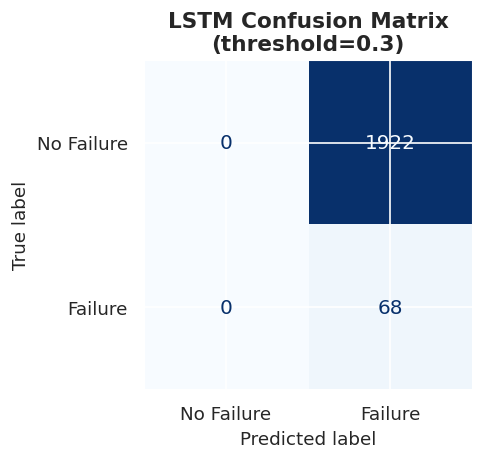

In [21]:
# Evaluate LSTM on test set
lstm_proba = lstm_model.predict(X_test_seq, verbose=0).flatten()

# Use 0.3 threshold (lower = more sensitive to failures)
THRESHOLD = 0.30
lstm_pred = (lstm_proba >= THRESHOLD).astype(int)

lstm_metrics = {
    'Accuracy' : accuracy_score(y_test_seq, lstm_pred),
    'Precision': precision_score(y_test_seq, lstm_pred, zero_division=0),
    'Recall'   : recall_score(y_test_seq, lstm_pred, zero_division=0),
    'F1 Score' : f1_score(y_test_seq, lstm_pred, zero_division=0),
    'ROC-AUC'  : roc_auc_score(y_test_seq, lstm_proba) if y_test_seq.sum() > 0 else 0.0,
    'y_pred'   : lstm_pred,
    'y_proba'  : lstm_proba,
}

print('LSTM Evaluation Results:')
for k, v in lstm_metrics.items():
    if isinstance(v, float):
        print(f'  {k:<12} : {v:.4f}')

print()
print(classification_report(y_test_seq, lstm_pred,
                             target_names=['No Failure', 'Failure'],
                             zero_division=0))

# Confusion matrix
fig, ax = plt.subplots(figsize=(5, 4))
cm = confusion_matrix(y_test_seq, lstm_pred)
ConfusionMatrixDisplay(cm, display_labels=['No Failure', 'Failure']).plot(
    ax=ax, cmap='Blues', colorbar=False
)
ax.set_title(f'LSTM Confusion Matrix\n(threshold={THRESHOLD})', fontweight='bold')
plt.tight_layout()
plt.savefig('lstm_confusion_matrix.png', bbox_inches='tight')
plt.show()

Model Evaluation & Comparison


In [22]:
# Compile all results
all_results = {name: {k: v for k, v in res.items() if isinstance(v, float)}
               for name, res in results.items()}
all_results['Bi-LSTM'] = {k: v for k, v in lstm_metrics.items() if isinstance(v, float)}

metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
results_df = pd.DataFrame(all_results).T[metrics_cols]
results_df = results_df.sort_values('ROC-AUC', ascending=False)

print('=' * 65)
print(' MODEL COMPARISON TABLE')
print('=' * 65)
display(results_df.style
    .format('{:.4f}')
    .background_gradient(cmap='YlGn', subset=metrics_cols)
    .set_caption('All metrics on held-out test set (20% of data)')
)

best_model_name = results_df['ROC-AUC'].idxmax()
print(f'\n Best model by ROC-AUC : {best_model_name}')
print(f'   ROC-AUC = {results_df.loc[best_model_name, "ROC-AUC"]:.4f}')
print(f'   F1 Score = {results_df.loc[best_model_name, "F1 Score"]:.4f}')

 MODEL COMPARISON TABLE


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Random Forest,0.9680,0.5179,0.8529,0.6444,0.9829
Gradient Boosting,0.9715,0.5545,0.8235,0.6627,0.9819
XGBoost,0.9545,0.4207,0.8971,0.5728,0.9772
Logistic Regression,0.8710,0.1955,0.8971,0.3211,0.9375
Bi-LSTM,0.0342,0.0342,1.0000,0.0661,0.4987



 Best model by ROC-AUC : Random Forest
   ROC-AUC = 0.9829
   F1 Score = 0.6444


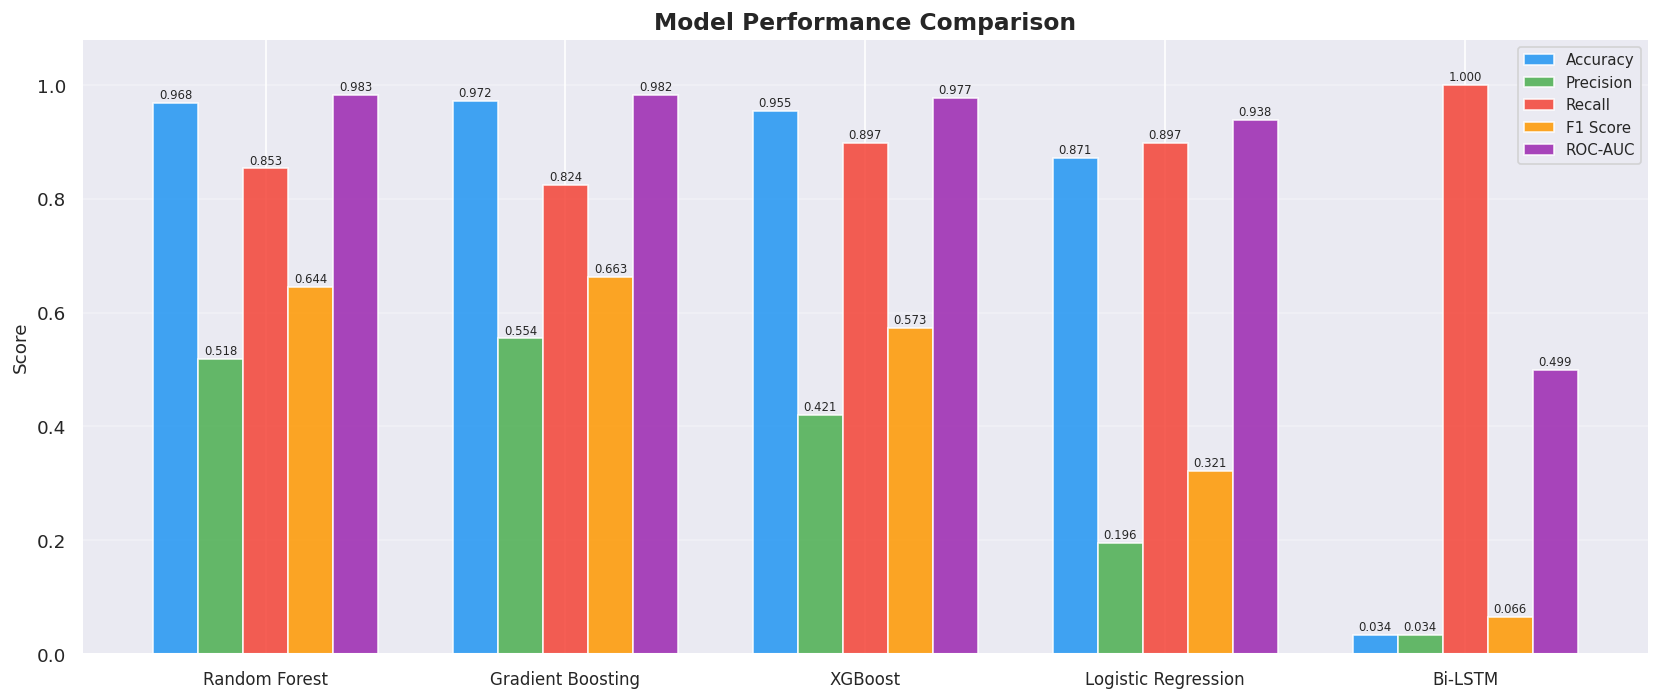

In [23]:
# Visual comparison — grouped bar chart
results_plot = results_df[metrics_cols].copy()
x = np.arange(len(results_plot))
width = 0.15
n_metrics = len(metrics_cols)
fig, ax = plt.subplots(figsize=(14, 6))

bar_colors = ['#2196F3', '#4CAF50', '#F44336', '#FF9800', '#9C27B0']
for i, (metric, color) in enumerate(zip(metrics_cols, bar_colors)):
    offset = (i - n_metrics / 2) * width + width / 2
    bars = ax.bar(x + offset, results_plot[metric], width,
                  label=metric, color=color, alpha=0.85, edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.003,
                f'{h:.3f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(results_plot.index, fontsize=10)
ax.set_ylabel('Score')
ax.set_ylim(0, 1.08)
ax.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight')
plt.show()

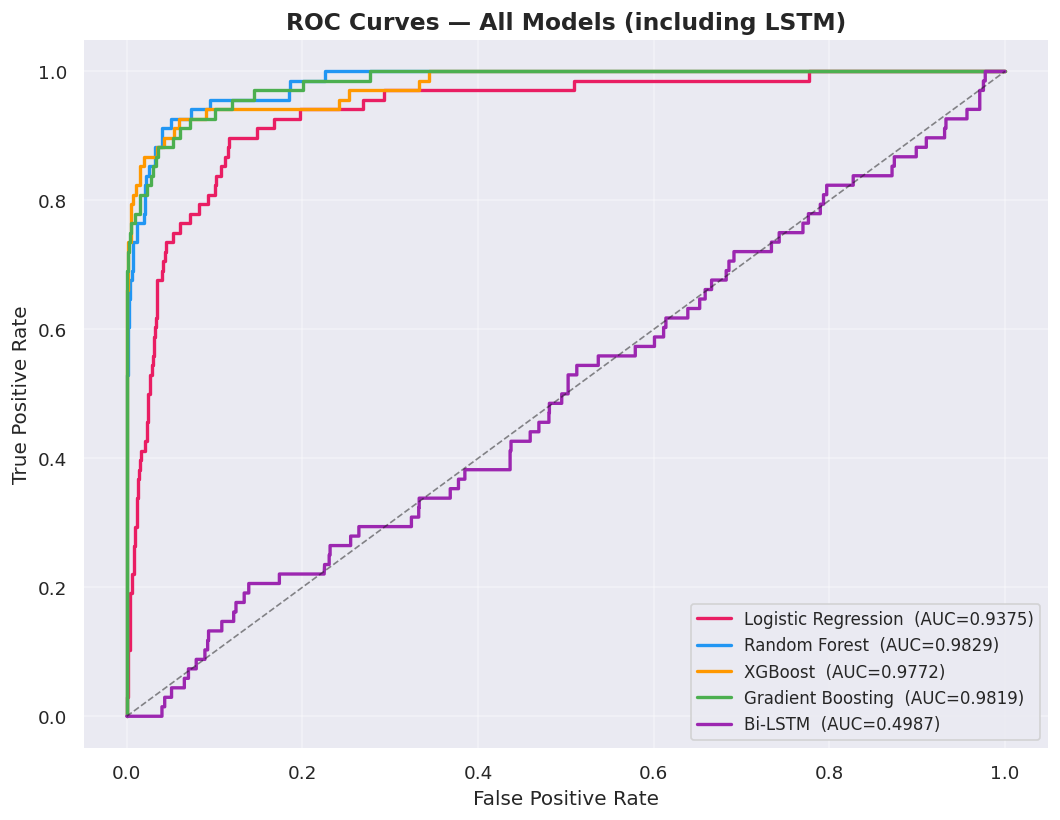

In [24]:
# Combined ROC curve (including LSTM)
fig, ax = plt.subplots(figsize=(9, 7))

all_probas = {n: r['y_proba'] for n, r in results.items()}
all_probas['Bi-LSTM'] = lstm_metrics['y_proba']
all_y_test = {n: y_test_fe.values for n in results}
all_y_test['Bi-LSTM'] = y_test_seq

colors_all = ['#E91E63', '#2196F3', '#FF9800', '#4CAF50', '#9C27B0']
for (name, proba), color in zip(all_probas.items(), colors_all):
    fpr, tpr, _ = roc_curve(all_y_test[name], proba)
    auc = roc_auc_score(all_y_test[name], proba)
    ax.plot(fpr, tpr, color=color, linewidth=2, label=f'{name}  (AUC={auc:.4f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models (including LSTM)', fontsize=14, fontweight='bold')
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.4)
plt.tight_layout()
plt.savefig('all_roc_curves.png', bbox_inches='tight')
plt.show()

Feature Importance & SHAP Explainability



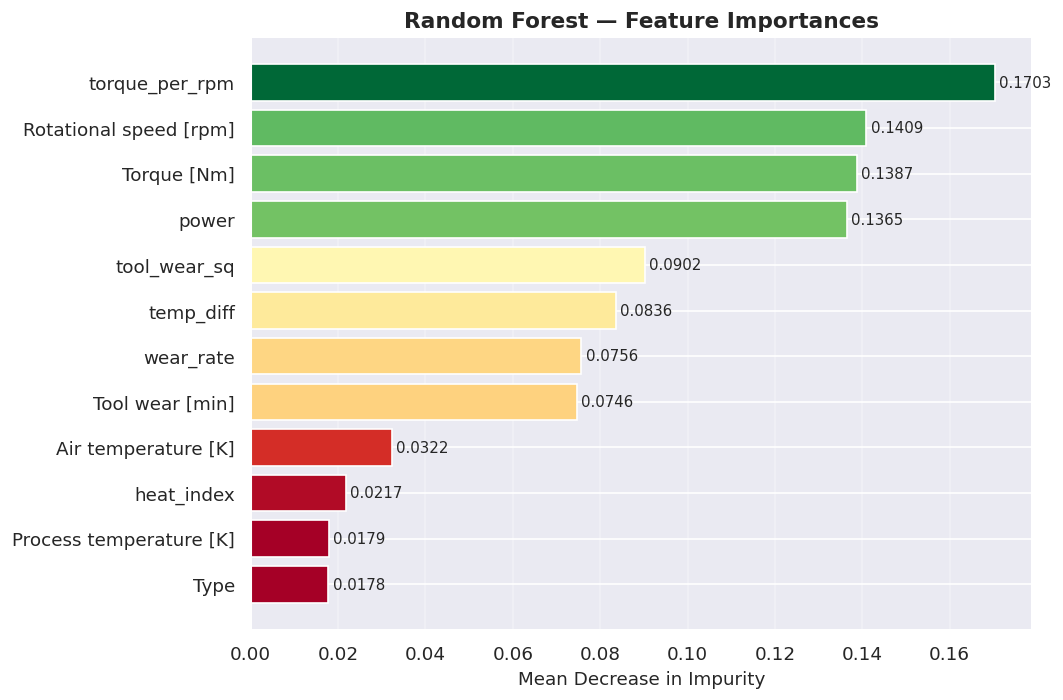

In [25]:
# Random Forest feature importances
rf_model = models['Random Forest']
importances = pd.Series(rf_model.feature_importances_, index=X_fe.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
cmap = plt.cm.get_cmap('RdYlGn')
norm_vals = (importances.values - importances.min()) / (importances.max() - importances.min())
bars = ax.barh(importances.index, importances.values,
               color=[cmap(v) for v in norm_vals], edgecolor='white')
for bar, val in zip(bars, importances.values):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.set_title('Random Forest — Feature Importances', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance_rf.png', bbox_inches='tight')
plt.show()

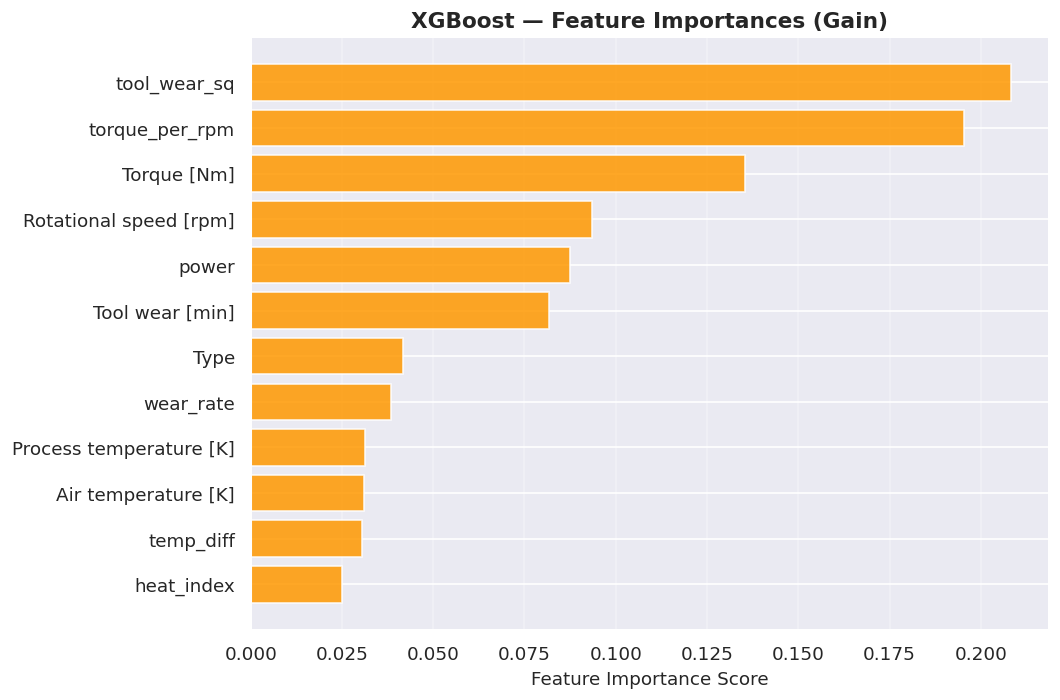

In [26]:
# XGBoost feature importances
xgb_model = models['XGBoost']
xgb_imp = pd.Series(xgb_model.feature_importances_, index=X_fe.columns)
xgb_imp = xgb_imp.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(xgb_imp.index, xgb_imp.values, color='#FF9800', alpha=0.85, edgecolor='white')
ax.set_title('XGBoost — Feature Importances (Gain)', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature Importance Score')
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('feature_importance_xgb.png', bbox_inches='tight')
plt.show()

Computing SHAP values (may take ~30 s)…


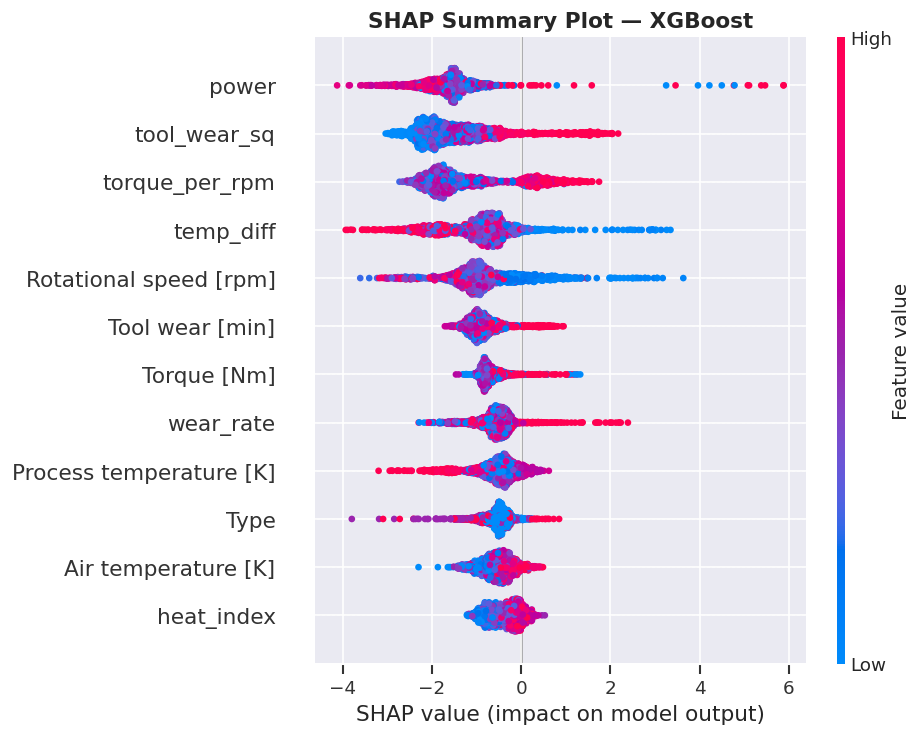

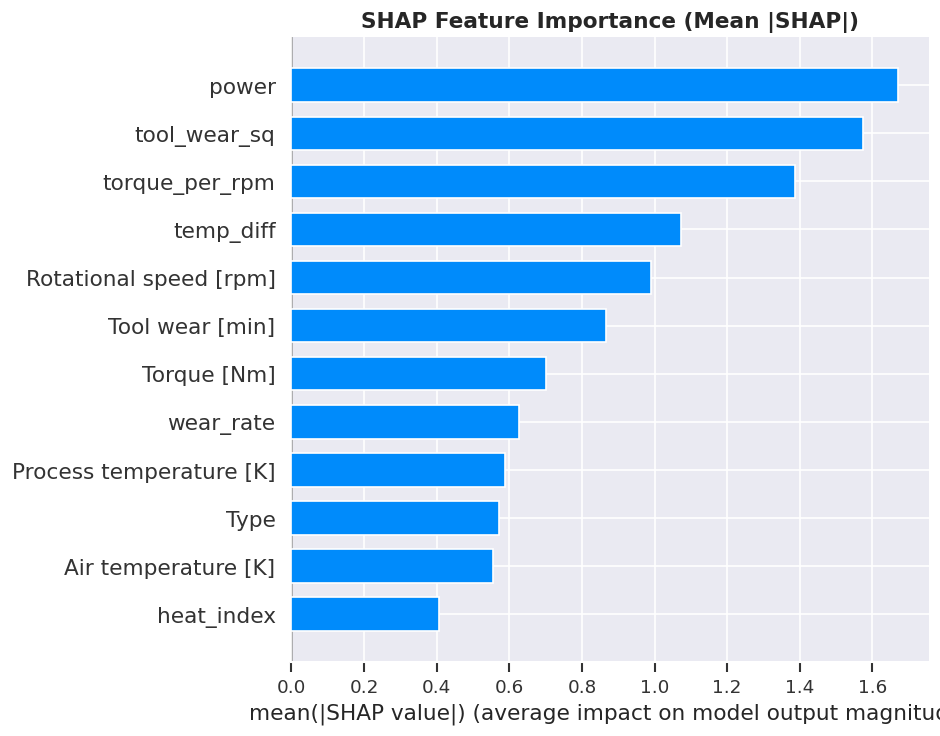

 SHAP analysis complete.


In [27]:
# SHAP analysis on XGBoost
print('Computing SHAP values (may take ~30 s)…')
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_fe_sc)

shap_df = pd.DataFrame(shap_values, columns=X_fe.columns)

# Summary plot
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test_fe_sc,
                  feature_names=X_fe.columns.tolist(),
                  plot_type='dot', show=False, max_display=12)
plt.title('SHAP Summary Plot — XGBoost', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_summary.png', bbox_inches='tight')
plt.show()

# Bar plot
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_fe_sc,
                  feature_names=X_fe.columns.tolist(),
                  plot_type='bar', show=False)
plt.title('SHAP Feature Importance (Mean |SHAP|)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_bar.png', bbox_inches='tight')
plt.show()

print(' SHAP analysis complete.')

Remaining Useful Life (RUL) Estimation


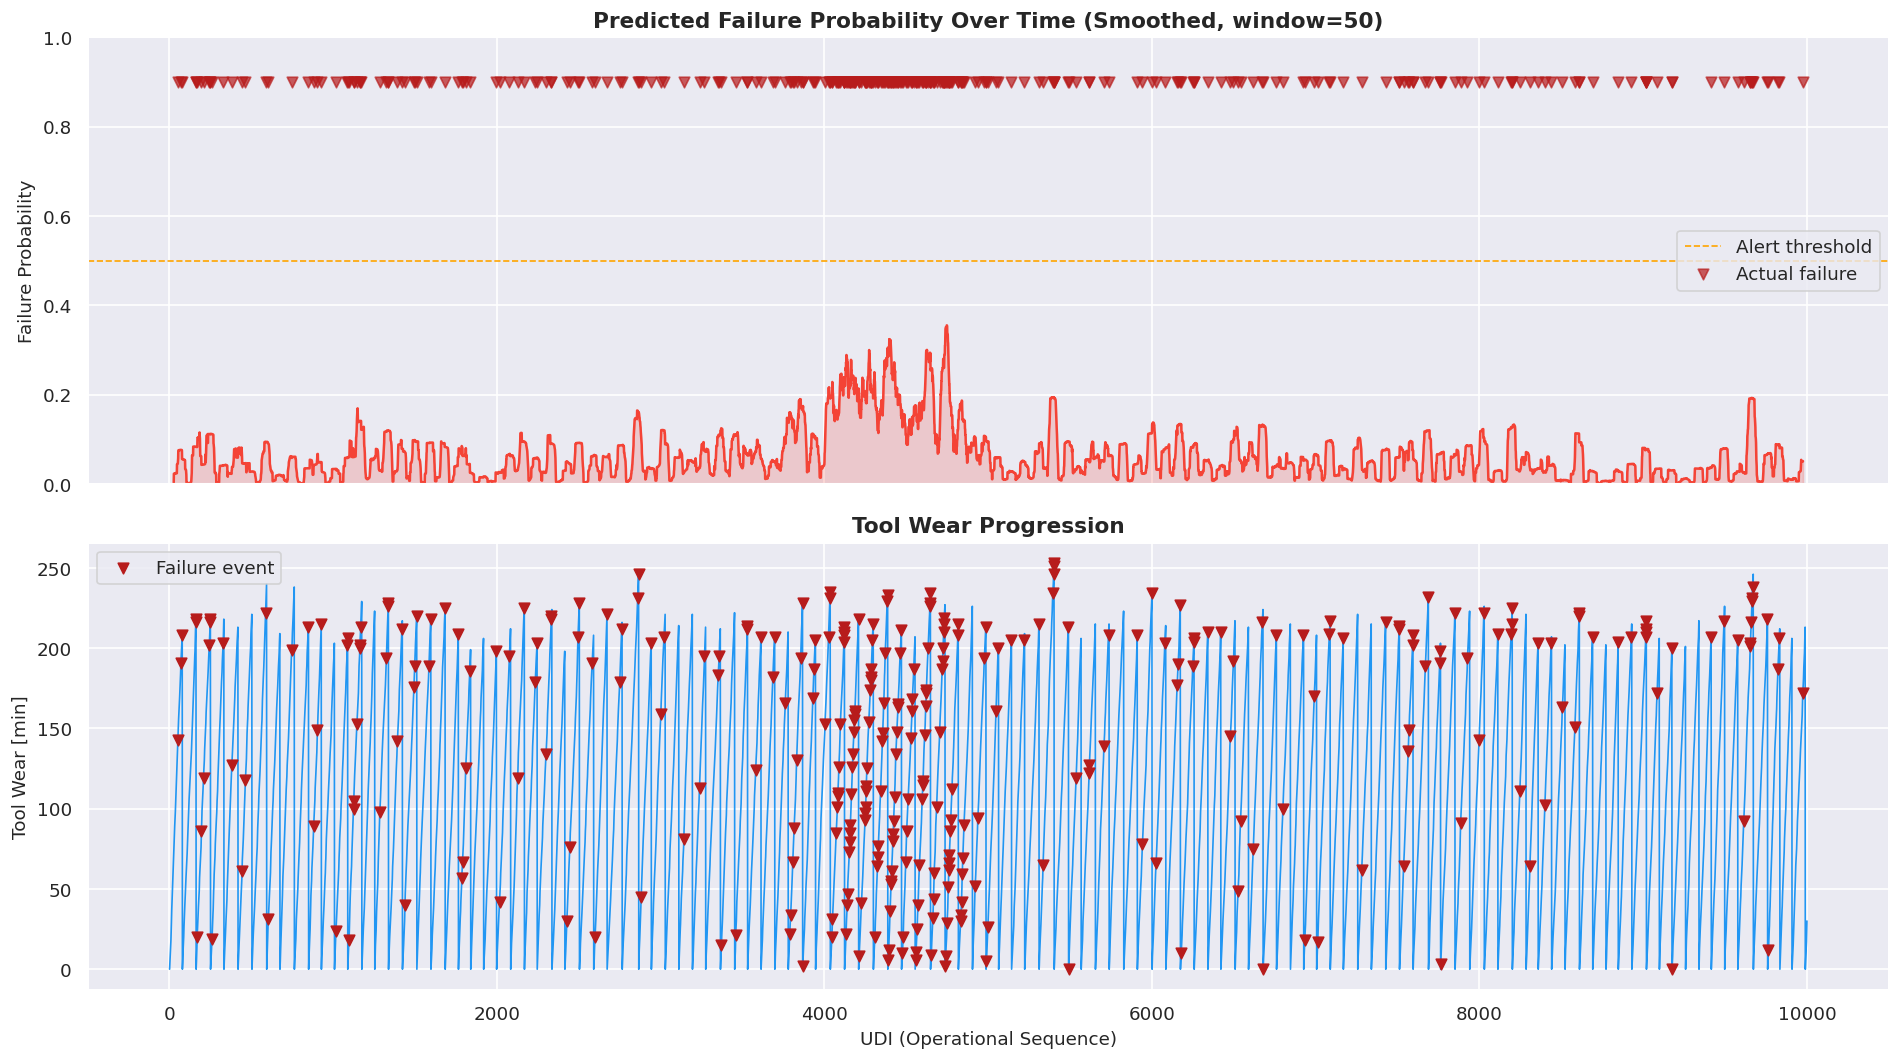


 Machines with RUL_Score < 0.3 should be scheduled for immediate maintenance.


In [28]:
# RUL proxy on full dataset
best_ml = models[best_model_name if best_model_name != 'Bi-LSTM' else 'XGBoost']
full_sc = scaler_fe.transform(X_fe)
failure_proba_full = best_ml.predict_proba(full_sc)[:, 1]

rul_df = df[['UDI', 'Tool wear [min]', 'Target', 'Failure Type']].copy()
rul_df['Failure_Proba'] = failure_proba_full
rul_df['RUL_Score']     = 1 - failure_proba_full

# Plot RUL trend
fig, axes = plt.subplots(2, 1, figsize=(16, 9), sharex=True)

# Smoothed failure probability
window_size = 50
smooth_proba = rul_df['Failure_Proba'].rolling(window_size, center=True).mean()
axes[0].plot(rul_df['UDI'], smooth_proba, color='#F44336', linewidth=1.5)
axes[0].fill_between(rul_df['UDI'], smooth_proba, alpha=0.2, color='#F44336')
axes[0].axhline(0.5, color='orange', linestyle='--', linewidth=1, label='Alert threshold')
failure_points = rul_df[rul_df['Target'] == 1]
axes[0].scatter(failure_points['UDI'], [0.9]*len(failure_points),
                color='#B71C1C', marker='v', s=40, label='Actual failure', alpha=0.7, zorder=5)
axes[0].set_ylabel('Failure Probability')
axes[0].set_title('Predicted Failure Probability Over Time (Smoothed, window=50)', fontweight='bold')
axes[0].legend()
axes[0].set_ylim(0, 1)

# Tool wear trend
axes[1].plot(rul_df['UDI'], rul_df['Tool wear [min]'], color='#2196F3', linewidth=1)
axes[1].scatter(failure_points['UDI'], failure_points['Tool wear [min]'],
                color='#B71C1C', marker='v', s=40, label='Failure event', zorder=5)
axes[1].set_ylabel('Tool Wear [min]')
axes[1].set_xlabel('UDI (Operational Sequence)')
axes[1].set_title('Tool Wear Progression', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('rul_trend.png', bbox_inches='tight')
plt.show()

print('\n Machines with RUL_Score < 0.3 should be scheduled for immediate maintenance.')

In [29]:
# High-risk machine identification
HIGH_RISK_THRESHOLD = 0.70

high_risk = rul_df[rul_df['Failure_Proba'] >= HIGH_RISK_THRESHOLD].copy()

high_risk = high_risk.merge(
    df[['UDI', 'Product ID', 'Type',
        'Tool wear [min]', 'Rotational speed [rpm]', 'Torque [Nm]']],
    on='UDI',
    how='left'
)

# Fix duplicate column names if created
high_risk.columns = high_risk.columns.str.replace('_x', '', regex=False)

print(f'High-risk records (P(failure) ≥ {HIGH_RISK_THRESHOLD}): {len(high_risk):,}')
print(f'   True positives : {high_risk["Target"].sum():,}')
print(f'   False alarms   : {(high_risk["Target"] == 0).sum():,}')
print()

display(
    high_risk[['UDI', 'Product ID', 'Type', 'Tool wear [min]',
               'Rotational speed [rpm]', 'Torque [Nm]',
               'Failure_Proba', 'RUL_Score', 'Failure Type']]
    .sort_values('Failure_Proba', ascending=False)
    .head(15)
    .style.format({'Failure_Proba': '{:.3f}', 'RUL_Score': '{:.3f}'})
    .background_gradient(cmap='Reds', subset=['Failure_Proba'])
)

High-risk records (P(failure) ≥ 0.7): 333
   True positives : 313
   False alarms   : 20



,UDI,Product ID,Type,Tool wear [min],Rotational speed [rpm],Torque [Nm],Failure_Proba,RUL_Score,Failure Type
0,51,L47230,L,143,2861,4.600000,1.000,0.000,Power Failure
305,8399,L55578,L,102,2617,12.100000,1.000,0.000,Power Failure
269,6800,M21659,M,100,2636,12.200000,1.000,0.000,Power Failure
282,7537,L54716,L,64,2579,12.500000,1.000,0.000,Power Failure
235,5335,M20194,M,65,2706,9.800000,1.000,0.000,Power Failure
163,4420,M19279,M,84,2676,10.800000,1.000,0.000,Power Failure
93,3868,M18727,M,2,2709,9.700000,1.000,0.000,Power Failure
79,3458,M18317,M,21,2639,12.000000,1.000,0.000,Power Failure
57,2234,L49413,L,179,2549,13.000000,1.000,0.000,Power Failure
82,3580,L50759,L,124,2672,11.800000,1.000,0.000,Power Failure


In [31]:
!pip freeze > requirements.txt